# Student Performance Prediction

## Exploratory Data Analysis (EDA)

### Project Overview

This project aims to predict a student's final grade based on factors such as study habits, attendance, and previous academic performance.

The dataset used for this project is the **Student Performance dataset**, which contains information about students' academic performance and personal, social, and school-related characteristics.

Exploratory Data Analysis (EDA) is the first stage of the project. It is used to understand the structure and characteristics of the dataset before building machine learning models.

### Objectives of the EDA

The main objectives of this analysis are to:

- Understand the structure and characteristics of the dataset.
- Examine the distribution of students' final grades.
- Analyze students' study time and attendance.
- Investigate the relationship between previous grades and final grades.
- Examine correlations between important variables.
- Identify potential outliers in the data.
- Investigate students with a final grade of zero.
- Identify useful insights that can guide the machine learning stage.

### Dataset

The analysis focuses on the **Mathematics student performance dataset**. The final grade, represented by **G3**, will be used as the target variable for the prediction model.

## 1. Import Libraries

The following Python libraries are used throughout the exploratory data analysis:

- **Pandas** – used for loading, manipulating, and analyzing the dataset.
- **NumPy** – used for numerical operations.
- **Matplotlib** – used for creating visualizations.
- **Seaborn** – used for statistical visualizations and improving the appearance of plots.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

The Student Performance dataset is loaded into a Pandas DataFrame using the `read_csv()` function.

The dataset file is stored in the `data` folder and is separated using a semicolon (`;`), which is why `sep=";"` is specified.

The DataFrame will be used for all subsequent exploratory data analysis.

In [2]:
df = pd.read_csv("../data/student-mat.csv", sep=";")

## 3. Preview the Dataset

The `head()` function is used to display the first five rows of the dataset.

This provides an initial view of the variables and the type of information recorded for each student.

In [3]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 4. Dataset Dimensions

The shape of the dataset is examined to determine the number of students and variables available for analysis.

The dataset contains **395 student records and 33 variables**.

Understanding the size of the dataset helps provide context for the subsequent analysis and modeling stages.

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 395
Number of columns: 33


## 5. Dataset Information

The `info()` function provides an overview of the dataset, including:

- The number of entries.
- The names of the variables.
- The data type of each variable.
- The number of non-null values.

This helps us understand the structure of the dataset and identify potential missing values or data-type issues.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

## 6. Descriptive Statistics

The `describe()` function provides summary statistics for the numerical variables in the dataset.

These statistics include the count, mean, standard deviation, minimum, maximum, and quartile values.

This gives an initial understanding of the distribution and variability of the numerical variables.

In [6]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## 7. Missing Value Analysis

Missing values are checked to determine whether any observations contain incomplete information.

Identifying missing values is important because missing data may affect the accuracy of statistical analysis and machine learning models.

The results show that the dataset does not contain missing values.

In [7]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

## 8. Analysis of the Final Grade (G3)

The variable `G3` represents the student's final grade and will be used as the **target variable** for the prediction model.

The mean, median, minimum, and maximum values are calculated to understand the overall distribution and range of students' final grades.

The final grade ranges from **0 to 20**, with an average of approximately **10.42**.

In [ ]:



print("Final Grade (G3) Statistics:")
print("Mean:", df["G3"].mean())
print("Median:", df["G3"].median())
print("Minimum:", df["G3"].min())
print("Maximum:", df["G3"].max())

Final Grade (G3) Statistics:
Mean: 10.415189873417722
Median: 11.0
Minimum: 0
Maximum: 20


### Distribution of Final Grades

A histogram is used to visualize how the final grades are distributed across the students.

The distribution shows that most students have final grades concentrated around the middle of the grading scale, while fewer students have very low or very high grades.

This provides an initial understanding of the target variable before developing the prediction models.

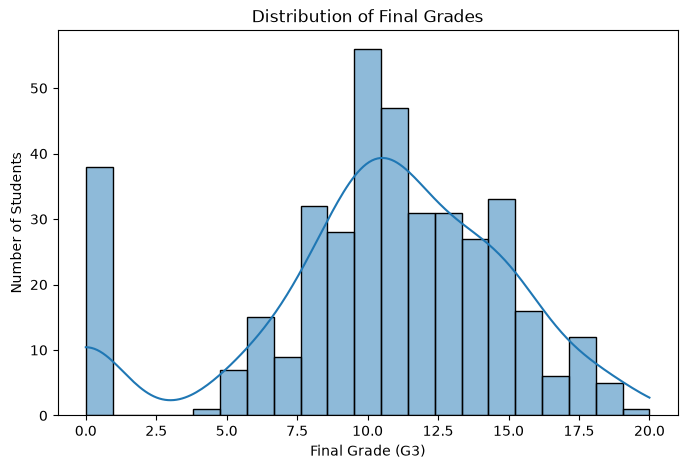

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(df["G3"], bins=21, kde=True)

plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")

plt.show()

### Interpretation

The histogram shows the distribution of students' final grades (`G3`) on a scale from 0 to 20.

Most students have final grades concentrated between approximately 8 and 15, with the highest frequency occurring around grades 10 and 11. This indicates that the majority of students achieved moderate final grades.

There is also a noticeable group of students with a final grade of 0. This group represents 38 students, or approximately 9.62% of the dataset, and will be investigated separately because these observations may have an important influence on the prediction model.

Overall, the target variable covers a wide range of final grades, providing sufficient variation for the regression analysis.

## 9. Study Time Analysis

The `studytime` variable represents the amount of weekly study time reported by each student.

The variable is divided into four categories, where higher categories represent greater amounts of weekly study time.

The frequency of students in each study-time category is examined to understand how study time is distributed across the dataset.

In [ ]:


studytime_counts = df["studytime"].value_counts().sort_index()

print(studytime_counts)

studytime
1    105
2    198
3     65
4     27
Name: count, dtype: int64


### Distribution of Weekly Study Time

A count plot is used to visualize the number of students in each study-time category.

The plot shows that study-time category 2 contains the largest number of students, followed by category 1. Categories 3 and 4 contain fewer students.

This indicates that most students in the dataset report relatively moderate or lower weekly study time.

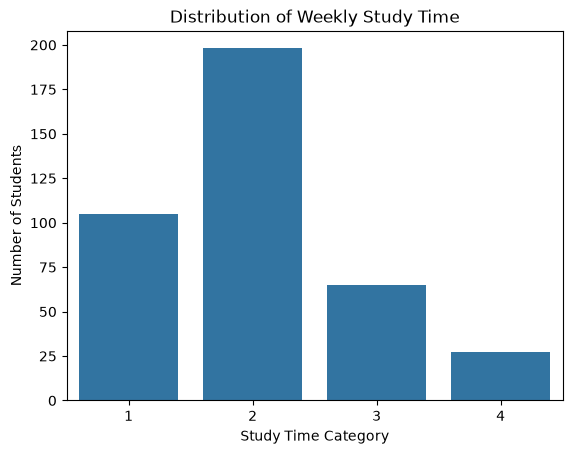

In [ ]:

sns.countplot(data=df, x="studytime")

plt.title("Distribution of Weekly Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Number of Students")

plt.show()

### Interpretation

The bar chart shows the distribution of students across the four weekly study-time categories.

Study-time category 2 has the highest number of students, with approximately 200 students. Category 1 is the second most common, while categories 3 and 4 contain considerably fewer students.

This indicates that most students in the dataset report relatively moderate or lower levels of weekly study time, while only a smaller proportion report higher study-time levels.

The uneven distribution across the categories should be considered when interpreting the relationship between study time and final grade.

### Study Time and Final Grade

The average final grade is calculated for each study-time category.

This allows us to examine whether students who report different amounts of weekly study time tend to have different average final grades.

In [ ]:

studytime_grade = df.groupby("studytime")["G3"].mean()
print(studytime_grade)

studytime
1    10.047619
2    10.171717
3    11.400000
4    11.259259
Name: G3, dtype: float64


### Average Final Grade by Study Time

The bar chart compares the average final grade across the four study-time categories.

Students in category 3 have the highest average final grade, while category 1 has the lowest average.

However, the relationship is not perfectly linear because category 4 has a slightly lower average than category 3.

Therefore, study time may have some relationship with final grade, but increasing study time alone does not necessarily result in a higher final grade.

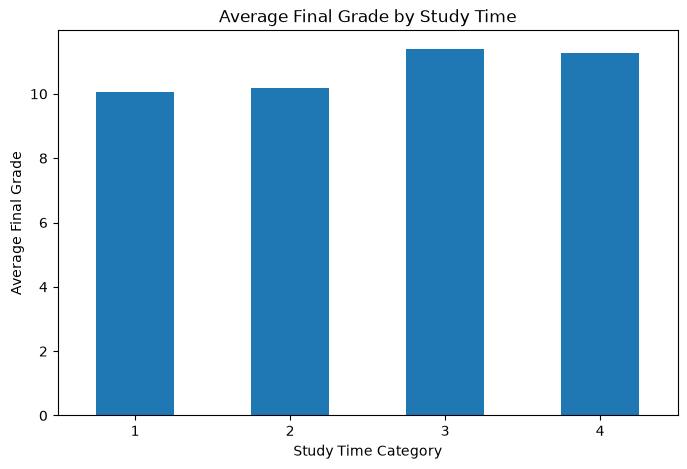

In [ ]:

studytime_grade.plot(kind="bar", figsize=(8, 5))

plt.title("Average Final Grade by Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Average Final Grade")

plt.xticks(rotation=0)

plt.show()

### Interpretation

The bar chart compares the average final grade (`G3`) across the four study-time categories.

Students in study-time category 3 have the highest average final grade, at approximately 11.4, followed closely by category 4 at approximately 11.3. Category 2 has an average of approximately 10.2, while category 1 has the lowest average at approximately 10.0.

Overall, students in the higher study-time categories tend to have slightly higher average final grades. However, the differences between the categories are relatively small, and the relationship is not perfectly linear because category 4 has a slightly lower average than category 3.

Therefore, study time appears to have a relatively weak association with final grade and should not be considered a strong predictor on its own.

## 10.Absence Analysis

The `absences` variable represents the number of school absences recorded for each student.

The mean, median, minimum, and maximum values are calculated to understand the overall level and spread of student absences.

This analysis helps determine whether students generally have low or high absence counts and whether there are students with unusually large numbers of absences.

In [ ]:


print("Absence Statistics:")
print("Mean:", df["absences"].mean())
print("Median:", df["absences"].median())
print("Minimum:", df["absences"].min())
print("Maximum:", df["absences"].max())

Absence Statistics:
Mean: 5.708860759493671
Median: 4.0
Minimum: 0
Maximum: 75


### Distribution of Student Absences

A histogram is used to examine the distribution of student absences.

The distribution is **right-skewed**, meaning that most students have relatively few absences, while a smaller number of students have much higher absence counts.

The long right tail is caused by students with unusually high numbers of absences.

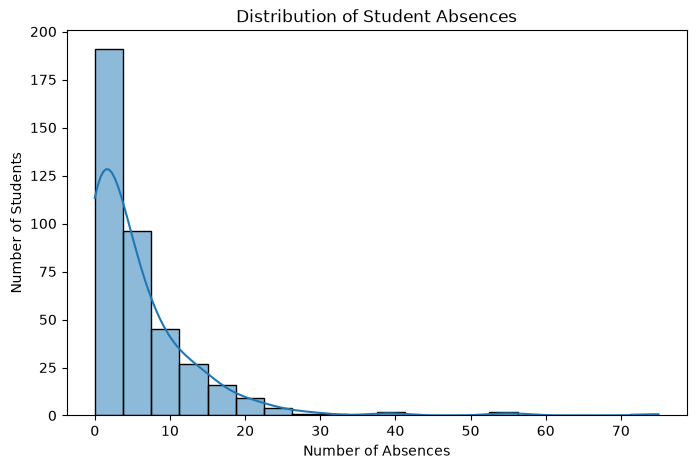

In [ ]:


plt.figure(figsize=(8, 5))

sns.histplot(df["absences"], bins=20, kde=True)

plt.title("Distribution of Student Absences")
plt.xlabel("Number of Absences")
plt.ylabel("Number of Students")

plt.show()

### Interpretation

The histogram shows the distribution of student absences.

Most students have a relatively small number of absences, with the highest concentration occurring at the lower end of the distribution. As the number of absences increases, the number of students decreases substantially.

The distribution is strongly **right-skewed**, with a long tail extending toward higher absence counts. A small number of students have unusually high numbers of absences, including some observations above 50 and one reaching approximately 75.

This indicates that the mean number of absences may be influenced by students with exceptionally high absence counts. These high values should therefore be considered carefully during subsequent analysis and modeling.

### Relationship Between Absences and Final Grade

A scatter plot is used to examine the relationship between the number of absences and the final grade.

The plot does not show a strong linear relationship between absences and final grade.

Although some students with high numbers of absences have lower grades, there are also students with several absences who achieve relatively high grades.

Therefore, absence count alone does not appear to be a strong linear predictor of final grade.

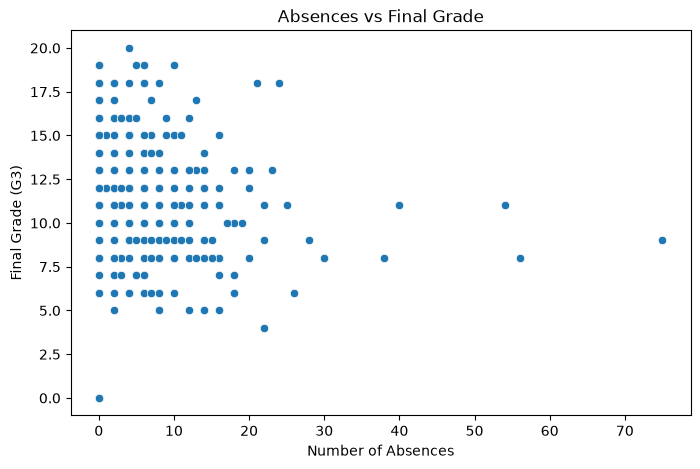

In [ ]:


plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="absences", y="G3")

plt.title("Absences vs Final Grade")
plt.xlabel("Number of Absences")
plt.ylabel("Final Grade (G3)")

plt.show()

### Interpretation

The scatter plot shows the relationship between the number of absences and the final grade (`G3`).

Most students are concentrated at relatively low numbers of absences, but their final grades vary considerably. Students with few absences can achieve both low and high final grades.

There are also a small number of students with very high absence counts. However, these students do not consistently have the lowest final grades. For example, some students with high numbers of absences still have moderate final grades.

Overall, the plot does not show a strong linear relationship between absences and final grade. This is consistent with the weak correlation between the two variables and suggests that absences alone may not be a strong predictor of final grade.

## 11. Analysis of Previous Grades

The variables `G1` and `G2` represent the student's grades from the first and second assessment periods, respectively.

These previous grades are examined alongside the final grade (`G3`) to understand whether earlier academic performance is associated with final performance.

The mean values of `G1`, `G2`, and `G3` are calculated for comparison.

In [ ]:


print("G1 Mean:", df["G1"].mean())
print("G2 Mean:", df["G2"].mean())
print("G3 Mean:", df["G3"].mean())

G1 Mean: 10.90886075949367
G2 Mean: 10.713924050632912
G3 Mean: 10.415189873417722


### First-Period Grade (G1) vs Final Grade (G3)

A scatter plot is used to examine the relationship between the first-period grade (`G1`) and the final grade (`G3`).

The plot shows a strong positive relationship. Students with higher `G1` grades generally tend to achieve higher final grades.

This suggests that previous academic performance may provide useful information for predicting the final grade.

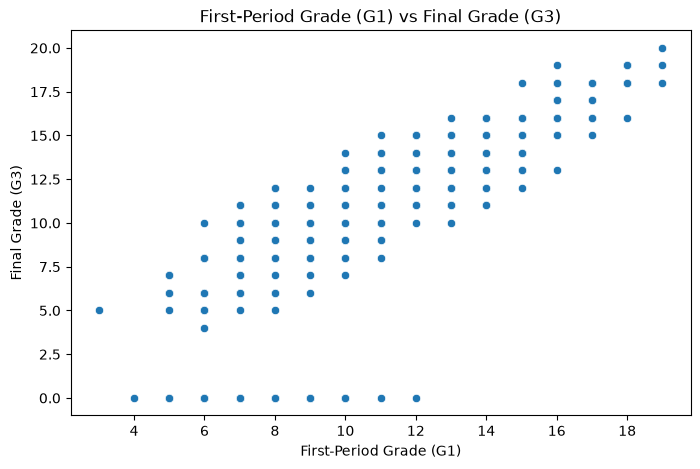

In [ ]:


plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="G1", y="G3")

plt.title("First-Period Grade (G1) vs Final Grade (G3)")
plt.xlabel("First-Period Grade (G1)")
plt.ylabel("Final Grade (G3)")

plt.show()

### Interpretation

The scatter plot shows the relationship between the first-period grade (`G1`) and the final grade (`G3`).

There is a strong positive relationship between the two variables. Students with higher first-period grades generally tend to achieve higher final grades.

The points follow a clear upward pattern, with students having higher `G1` values generally concentrated at higher `G3` values. This indicates that previous academic performance is strongly associated with final academic performance.

A group of students with `G3 = 0` can also be observed across several `G1` values. These observations are retained because they may represent valid outcomes in the dataset.

Overall, `G1` appears to be an important variable for predicting the final grade.

### Second-Period Grade (G2) vs Final Grade (G3)

A scatter plot is used to examine the relationship between the second-period grade (`G2`) and the final grade (`G3`).

The plot shows a very strong positive relationship. Students with higher `G2` grades generally tend to achieve higher final grades.

Among the variables examined so far, previous grades appear to provide substantially more information about final performance than study time or absence count alone.

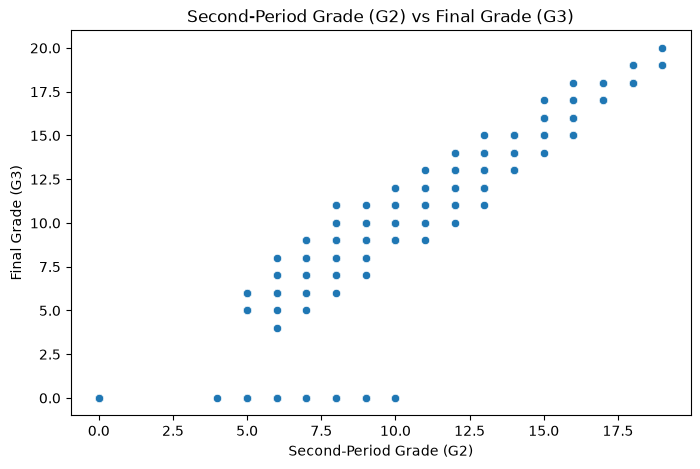

In [ ]:


plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="G2", y="G3")

plt.title("Second-Period Grade (G2) vs Final Grade (G3)")
plt.xlabel("Second-Period Grade (G2)")
plt.ylabel("Final Grade (G3)")

plt.show()

### Interpretation

The scatter plot shows the relationship between the second-period grade (`G2`) and the final grade (`G3`).

There is a very strong positive relationship between the two variables. As the `G2` grade increases, the final grade (`G3`) generally increases as well.

The points follow a clear upward pattern, indicating that students who perform better in the second assessment period tend to achieve higher final grades.

A small group of students with `G3 = 0` can also be observed across different `G2` values. These observations are retained because they represent valid records in the dataset.

Overall, `G2` appears to be a particularly important variable for predicting the final grade. This observation is consistent with the correlation analysis, where `G2` has the strongest positive correlation with `G3` among the selected variables.

## 12. Correlation Analysis

Correlation analysis is used to examine the strength and direction of the linear relationships between the selected variables.

Correlation values range from **-1 to +1**:

- **+1** indicates a strong positive relationship.
- **0** indicates little or no linear relationship.
- **-1** indicates a strong negative relationship.

The analysis focuses on study time, absences, previous grades (`G1` and `G2`), and the final grade (`G3`).

In [ ]:

correlation = df[["studytime", "absences", "G1", "G2", "G3"]].corr()
print(correlation)

           studytime  absences        G1        G2        G3
studytime   1.000000 -0.062700  0.160612  0.135880  0.097820
absences   -0.062700  1.000000 -0.031003 -0.031777  0.034247
G1          0.160612 -0.031003  1.000000  0.852118  0.801468
G2          0.135880 -0.031777  0.852118  1.000000  0.904868
G3          0.097820  0.034247  0.801468  0.904868  1.000000


### Correlation Heatmap

A correlation heatmap is used to visualize the relationships between the selected variables.

The heatmap shows that `G2` has the strongest positive correlation with `G3`, followed by `G1`.

In comparison, study time and absences have much weaker correlations with the final grade.

These results suggest that previous academic performance may provide substantially more predictive information about final performance than study time or absence count alone.

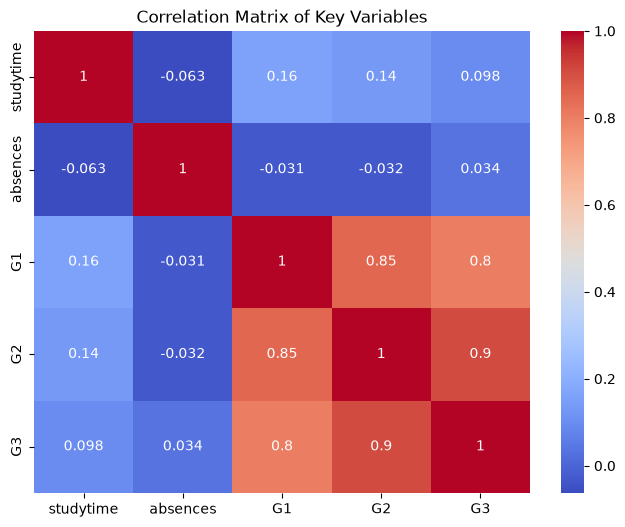

In [ ]:

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
)
plt.title("Correlation Matrix of Key Variables")
plt.show()

### Interpretation

The correlation matrix shows the strength and direction of the linear relationships between the selected variables.

The strongest positive correlation with the final grade (`G3`) is observed for `G2`, with a correlation of **0.90**. This indicates a very strong positive linear relationship between second-period and final grades.

`G1` also has a strong positive correlation with `G3`, with a correlation of **0.80**. This indicates that students with higher first-period grades generally tend to achieve higher final grades.

In contrast, `studytime` has a weak positive correlation with `G3` of approximately **0.098**, while `absences` has a very weak positive correlation of approximately **0.034**. This suggests that these variables have relatively weak linear relationships with the final grade when considered individually.

The heatmap also shows a strong correlation of **0.85 between `G1` and `G2`**, indicating that students who perform well in the first assessment period generally also tend to perform well in the second assessment period.

Overall, previous academic performance, particularly `G2`, appears to provide substantially more predictive information about the final grade than study time or absences.

## 13. Dataset Variables

The names of all variables in the dataset are displayed to provide a complete overview of the available information.

The dataset contains academic, demographic, social, and school-related variables.

Although the dataset contains 33 variables, the modeling stage will focus on a selected set of variables based on the project objective and the findings from the exploratory analysis.

In [ ]:

print("Dataset variables:")
for column in df.columns:
    print("-", column)

Dataset variables:
- school
- sex
- age
- address
- famsize
- Pstatus
- Medu
- Fedu
- Mjob
- Fjob
- reason
- guardian
- traveltime
- studytime
- failures
- schoolsup
- famsup
- paid
- activities
- nursery
- higher
- internet
- romantic
- famrel
- freetime
- goout
- Dalc
- Walc
- health
- absences
- G1
- G2
- G3


## 14. Identify Variable Types

The variables are separated into numerical and categorical variables based on their data types.

Numerical variables contain quantitative values that can be used in numerical calculations, while categorical variables represent groups or categories.

Identifying the variable types is important because different types of variables may require different preprocessing techniques during the machine learning stage.

In [ ]:


numerical_columns = df.select_dtypes(
        include=["number"]
    ).columns

categorical_columns = df.select_dtypes(
        include=["str"]
    ).columns

print("Numerical variables:")
print(list(numerical_columns))

print("\nCategorical variables:")
print(list(categorical_columns))

Numerical variables:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Categorical variables:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


## 15. Outlier Analysis

Outlier analysis is performed to identify observations that are unusually far from the rest of the data.

The **Interquartile Range (IQR)** method is used to identify potential outliers.

The IQR is calculated as:

**IQR = Q3 - Q1**

where:

- **Q1** is the first quartile (25th percentile).
- **Q3** is the third quartile (75th percentile).

Potential outliers are identified using the following boundaries:

- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

The analysis is performed on important variables including age, study time, failures, absences, G1, G2, and G3.

In [ ]:


important_variables = [
    "age",
    "studytime",
    "failures",
    "absences",
    "G1",
    "G2",
    "G3"
]

for column in important_variables:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"{column}: {len(outliers)} potential outliers")


age: 1 potential outliers
studytime: 27 potential outliers
failures: 83 potential outliers
absences: 15 potential outliers
G1: 0 potential outliers
G2: 13 potential outliers
G3: 0 potential outliers


### Visualizing Potential Outliers

Boxplots are used to visually identify potential outliers in the selected variables.

Values that appear beyond the whiskers of a boxplot may be considered potential outliers according to the IQR method.

However, a potential outlier is not necessarily an incorrect observation. It may represent a genuine characteristic of a student in the dataset.

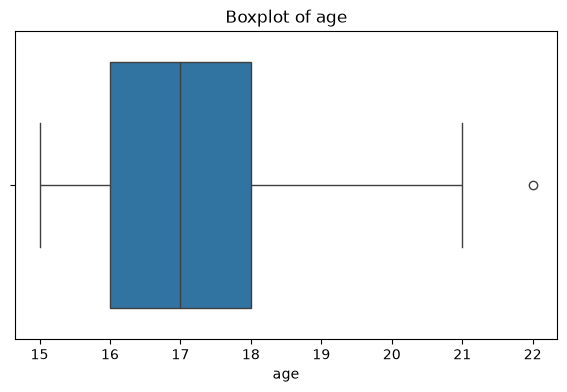

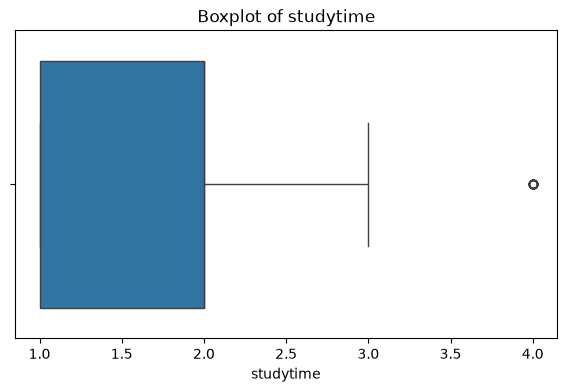

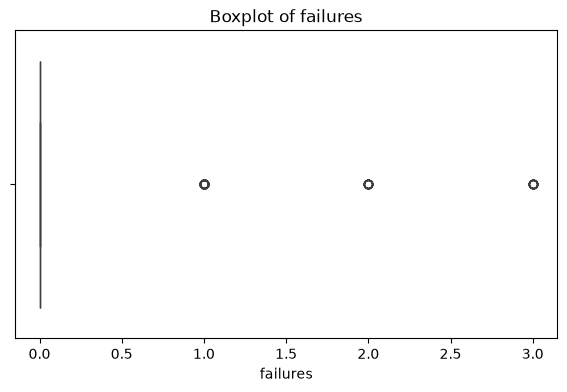

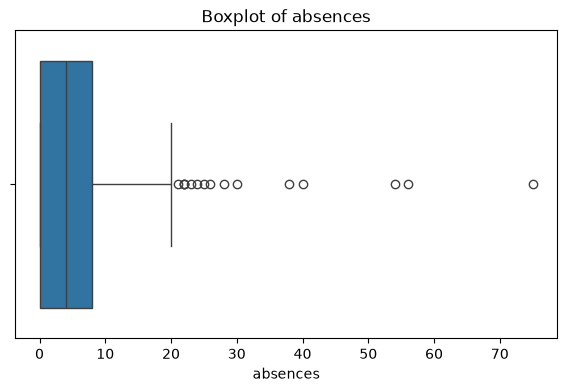

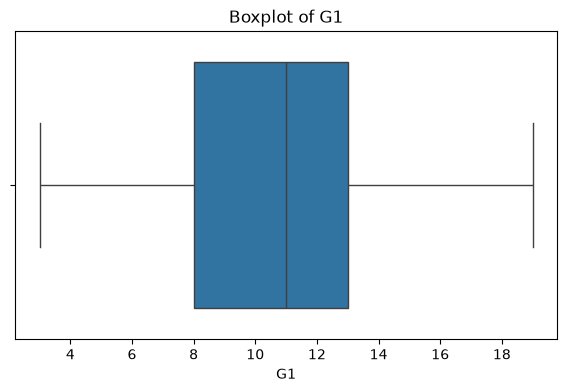

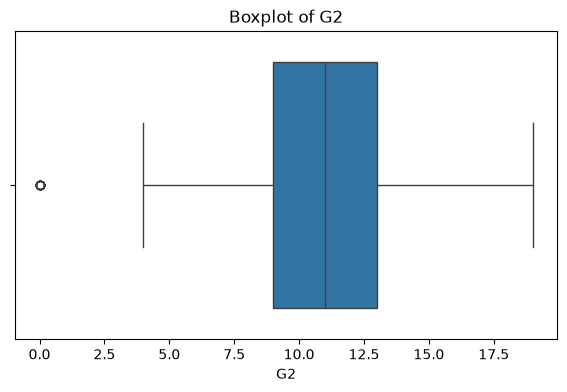

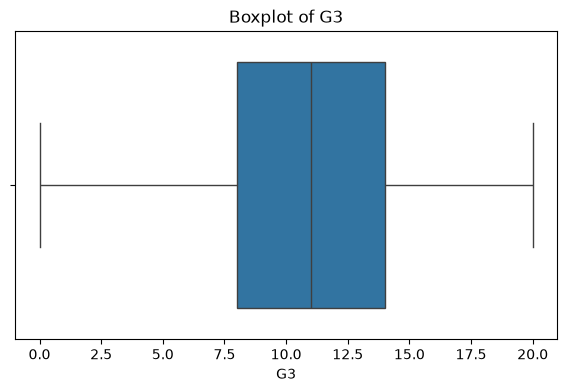

In [ ]:

variables_to_plot = [
    "age",
    "studytime",
    "failures",
    "absences",
    "G1",
    "G2",
    "G3"
]

for column in variables_to_plot:

    plt.figure(figsize=(7, 4))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.show()

### Interpretation of Boxplots and Potential Outliers

The boxplots were used to identify potential outliers in the selected variables using the Interquartile Range (IQR) method.

- **Age:** Most students are between approximately 16 and 18 years old. One observation at age 22 appears as a potential outlier. However, this may represent a valid student observation rather than an error.

- **Study Time:** Most observations fall between categories 1 and 2. Category 4 appears as a potential outlier because relatively few students belong to this category. Since `studytime` is a categorical/ordinal variable, this should not automatically be treated as an erroneous observation.

- **Failures:** Most students have zero previous failures, while observations with 1, 2, or 3 failures appear as potential outliers. These values represent students with previous failures and are therefore valid observations rather than necessarily incorrect data.

- **Absences:** The `absences` variable contains several potential outliers at higher values. This is consistent with the right-skewed distribution observed earlier, where most students have relatively few absences while a small number have much higher absence counts.

- **G1:** The first-period grades are relatively well distributed, with no obvious extreme outliers visible in the boxplot.

- **G2:** Most second-period grades are concentrated within the central range. A very low value, particularly `G2 = 0`, appears as a potential outlier.

- **G3:** The final grades are spread across the full 0–20 range, but the boxplot does not identify the extreme values as statistical outliers using the IQR rule. The observations with `G3 = 0` are therefore not automatically considered outliers by this method.

### Outlier Handling Decision

The presence of a potential outlier does not necessarily mean that the observation is incorrect. Many of the identified observations represent realistic student characteristics, such as higher absences, previous failures, or lower grades.

Therefore, the potential outliers will **not be removed automatically**. Removing valid observations could result in loss of useful information and may negatively affect the ability of the prediction models to learn from different types of student performance.

The observations will be retained for the modeling stage unless further investigation provides evidence that a value is an actual data-entry error.

### Absence Outliers

The boxplot for `absences` provides a closer look at unusually high absence counts.

Several observations may appear as potential outliers because the distribution of absences is strongly right-skewed.

These observations will not be removed automatically because high absence counts may represent valid student records rather than data errors.

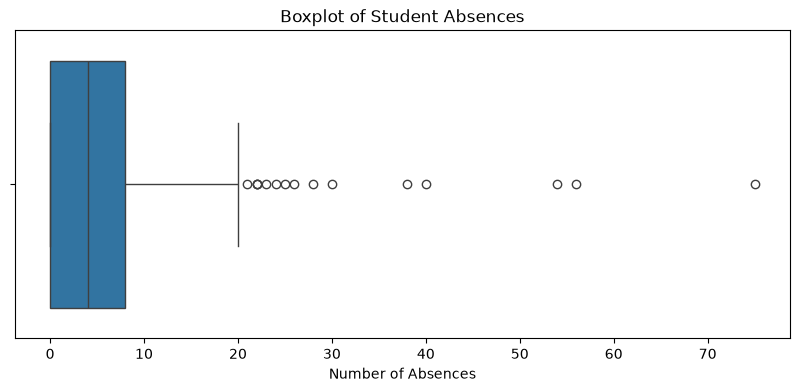

In [ ]:

plt.figure(figsize=(10, 4))

sns.boxplot(x=df["absences"])

plt.title("Boxplot of Student Absences")
plt.xlabel("Number of Absences")
plt.show()

### Interpretation

The boxplot shows the distribution of student absences and highlights several potential outliers.

Most students have relatively low numbers of absences, with the central 50% of observations concentrated below approximately 10 absences. The median is around 4 absences.

The upper whisker extends to approximately 20 absences, after which several observations are identified as potential outliers. Some students have substantially higher absence counts, including values above 50 and one observation at approximately 75 absences.

These observations are consistent with the right-skewed distribution observed in the absence histogram.

The potential outliers will not be removed automatically because high absence counts may represent genuine student records rather than data-entry errors. They will therefore be retained for the modeling stage unless further evidence indicates that they are invalid observations.

## 16. Investigation of Students With a Final Grade of 0

The final grade (`G3`) contains some students with a value of 0.

These observations are investigated separately to determine how common they are and to understand their characteristics.

This is important because a final grade of 0 may represent a genuine student outcome and should not automatically be treated as a data error.

In [ ]:

zero_final_grades = (df["G3"] == 0).sum()

print("Students with G3 = 0:", zero_final_grades)

# Calculate the percentage of students with G3 = 0.

zero_percentage = (zero_final_grades / len(df)) * 100

print(f"Percentage of students with G3 = 0: {zero_percentage:.2f}%")

Students with G3 = 0: 38
Percentage of students with G3 = 0: 9.62%


### Characteristics of Students With G3 = 0

The average study time, absences, first-period grade (`G1`), and second-period grade (`G2`) are calculated for students whose final grade is 0.

These values can be compared with the overall student population to identify differences between students with a zero final grade and the rest of the dataset.

In [ ]:


zero_grade_students = df[df["G3"] == 0]

# Compare their key variables.

print("Average values for students with G3 = 0:")
print(
    zero_grade_students[
        ["studytime", "absences", "G1", "G2"]
    ].mean()
)

Average values for students with G3 = 0:
studytime    1.973684
absences     0.000000
G1           7.526316
G2           4.657895
dtype: float64


### Comparison With the Overall Student Population

The average values for all students are compared with the averages for students who received a final grade of 0.

There are **38 students with G3 = 0**, representing approximately **9.62% of the dataset**.

These observations are retained because they are valid records and may contain useful information for the prediction task.

Removing them could prevent the machine learning models from learning how to predict very low final grades.

In [ ]:


comparison = pd.DataFrame({
    "All Students": df[["studytime", "absences", "G1", "G2", "G3"]].mean(),
    "G3 = 0 Students": zero_grade_students[
        ["studytime", "absences", "G1", "G2", "G3"]
    ].mean()
})

print(comparison)


           All Students  G3 = 0 Students
studytime      2.035443         1.973684
absences       5.708861         0.000000
G1            10.908861         7.526316
G2            10.713924         4.657895
G3            10.415190         0.000000


# EDA Conclusions

The exploratory data analysis provided several important insights into the Student Performance dataset:

1. The dataset contains **395 students and 33 variables**, providing information about students' academic, demographic, social, and school-related characteristics.

2. The final grade (`G3`) ranges from **0 to 20**, with a mean of approximately **10.42**. The distribution is concentrated mainly around the middle of the grading scale, although there is a noticeable group of **38 students with a final grade of 0**, representing approximately **9.62% of the dataset**.

3. **Study time** is unevenly distributed across the four categories. Category 2 contains the largest number of students, while categories 3 and 4 contain considerably fewer students. Students in the higher study-time categories have slightly higher average final grades; however, the differences are relatively small and the relationship is not perfectly linear.

4. **Absences** are strongly right-skewed. Most students have relatively few absences, while a small number have substantially higher absence counts, including observations above 50. The scatter plot and correlation analysis indicate that absences have only a **very weak linear relationship with final grade** (correlation ≈ 0.034).

5. **Previous academic performance is strongly associated with final performance.** The scatter plots show clear positive relationships between both `G1` and `G3`, and `G2` and `G3`. The correlation analysis confirms these relationships, with correlations of approximately **0.80 for G1-G3** and **0.90 for G2-G3**.

6. `G1` and `G2` are also strongly correlated with each other, with a correlation of approximately **0.85**. This indicates that students who perform well in the first assessment period generally tend to perform well in the second assessment period as well.

7. The boxplots identified several potential outliers, particularly in **absences**, as well as some observations in age, study time, failures, and previous grades. However, potential outliers are not necessarily errors. These observations may represent genuine student characteristics and were therefore **retained rather than removed automatically**.

8. The analysis of students with `G3 = 0` indicates that these observations should also be retained. They represent valid records and may provide useful information for the prediction model, particularly when predicting very low final grades.

## Key Insights for Modeling

Overall, the EDA suggests that **previous academic performance, particularly `G2`, is likely to provide substantially more predictive information about the final grade than study time or absences alone**.

Nevertheless, `studytime` and `absences` will still be considered as candidate features because the purpose of the project is to predict final performance using a combination of study habits, attendance, and previous academic performance.

The selected features for the modeling stage are:

- `studytime`
- `absences`
- `G1`
- `G2`

The target variable is:

- `G3`

The next stage of the project will involve preprocessing the selected features, splitting the data into training and testing sets, and developing regression models to predict the student's final grade.